In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import metrics

df = pd.read_csv('data/komdigi_hoaks.csv')

df['teks'] = df['title'].fillna('') + ' ' + df['excerpt'].fillna('')
df = df[df['teks'].str.strip() != ''].reset_index(drop=True)

print("Total data hoaks:", len(df))
df[['title', 'teks']].head()

Total data hoaks: 4176


,title,teks
0,[HOAKS] Tautan Pencairan BSU September 2026 Se...,[HOAKS] Tautan Pencairan BSU September 2026 Se...
1,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...
2,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...
3,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...
4,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...


In [2]:
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['teks'])

print("Bentuk matriks TF-IDF:", X.shape)

Bentuk matriks TF-IDF: (4176, 1000)


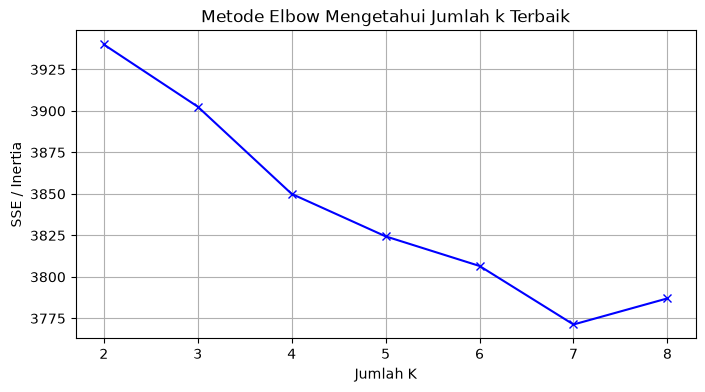

In [3]:
sse = []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, sse, 'bx-')
plt.xlabel('Jumlah K')
plt.ylabel('SSE / Inertia')
plt.title('Metode Elbow Mengetahui Jumlah k Terbaik')
plt.grid(True)
plt.show()

In [4]:
k_terbaik = 4
kmeans = KMeans(n_clusters=k_terbaik, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

sil_score = metrics.silhouette_score(X, df['cluster'])
print(f"Silhouette Score K-Means: {sil_score:.4f}")

print("\nJumlah data per klaster:")
print(df['cluster'].value_counts().sort_index())

Silhouette Score K-Means: 0.0235

Jumlah data per klaster:
cluster
0     219
1    3103
2     541
3     313
Name: count, dtype: int64


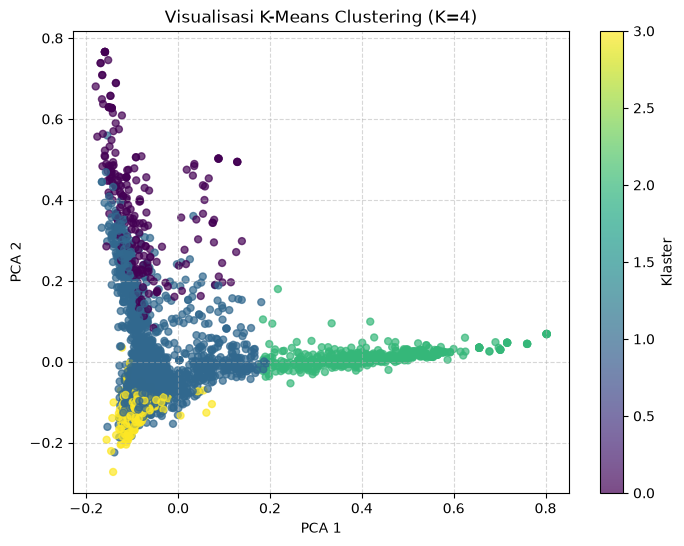

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df['pca1'], df['pca2'], c=df['cluster'], cmap='viridis', s=25, alpha=0.7)
plt.title(f'Visualisasi K-Means Clustering (K={k_terbaik})')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Klaster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [6]:
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()

print("Kata Kunci Dominan per Klaster:")
for i in range(k_terbaik):
    top_terms = [terms[ind] for ind in order_centroids[i, :7]]
    print(f"Kluster {i}: {', '.join(top_terms)}")

Kata Kunci Dominan per Klaster:
Kluster 0: lowongan, kerja, tautan, pt, hoaks, pekerjaan, pendaftaran
Kluster 1: hoaks, di, video, dan, tautan, yang, indonesia
Kluster 2: akun, mengatasnamakan, whatsapp, kabupaten, bupati, hoaks, facebook
Kluster 3: presiden, prabowo, hoaks, jokowi, subianto, gibran, dan


### Kesimpulan K-Means:
1. Melalui metode Elbow, nilai K yang optimal untuk mengelompokkan data hoaks ini adalah K=4.
2. K-Means berhasil membagi seluruh dokumen ke dalam 4 kelompok topik yang berbeda.
3. K-Means tidak memiliki konsep noise/outlier, sehingga semua data dipaksa masuk ke salah satu klaster.